<div align="center">

# Classification of Biomedical Publication Types Using Transformer Models

### **Weronika Mądro**

### 473193

</div>

## 1. Introduction

Biomedical research is growing rapidly, and PubMed publishes thousands of new articles every month. This makes it harder for researchers and clinicians to quickly identify the papers that are most relevant to their work. Different publication types, such as case reports or comparative studies, serve different purposes and provide different levels of evidence. Automatically recognizing these types could support tasks like literature review, evidence summarization or screening.

#### 1.1. Objective

The objective of this study is to evaluate the effectiveness of transformer-based models in classifying PubMed abstracts into standardized biomedical publication types. Specifically, the task formulates a multi-class classification problem over five classes: **randomized controlled trial**, **comparative study**, **editorial**, **case reports**, **news** and **historical article**.

Although publication types are part of the official PubMed indexing pipeline, they are not always available at the time researchers or analysts first encounter new manuscripts or preprints. Automated classification could therefore add value by enriching biomedical content with structured metadata earlier in the publication lifecycle. This can accelerate literature screening for systematic reviews, clinical guideline development and horizon scanning activities. Additionally, publishers and data platforms could use automated tagging to improve discoverability, filtering the content, reducing manual indexing workload and enabling more efficient downstream analytics.



I benchmark four large language models:

- **PubMedBERT** — pretrained from scratch on PubMed abstracts (biomedical domain)
- **BioClinicalBERT** — pretrained on MIMIC clinical notes + biomedical text
- **Baseline Bert** - general-purpose language model, trained on Wikipedia + BooksCorpus
- **TinyBert** — compressed/distilled version of BERT optimized for speed and reduced parameter size

The evaluation compares models based on accuracy, macro-averaged F1, precision, recall and ROC AUC.

#### 1.2. Data Source

The dataset used in this work was constructed directly from the **PubMed API (NCBI Entrez E-utilities)**. Publication-type labels were obtained using structured publication type filters. Abstracts and metadata were retrieved via esearch and efetch endpoints. 

## 2. Data Import and Preprocessing

### 2.1. Virtual environment and libraries

The first step is creating a new virtual environment and because of that, I need o install a few libraries. Later on, I import the necesessary libraries.

In [ ]:
#pip install requests pandas scikit-learn datasets transformers matplotlib tabulate

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
  Using cached huggingface_hu

In [ ]:
#pip install "torch>=2.1"

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 1.6 MB/s  0:00:43m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.9 MB/s  0:00:00 eta 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torch]32m5/6 [torch]Safe]
Note: you may need to restart the kernel to use updated packages.


In [182]:
import requests
import time
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
import numpy as np
from scipy.special import softmax
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold


### 2.2. Getting data via API

One of the project's requirements was to incependently collect the data. First idea, was to use a dataset from HugginFace, but after a careful consideration, I decided that a better fulfillment of this independent collection argument would be to take the original data from already existing and usable by population source. The choice was the PubMed. 

PubMed is a part of National Library of Medicine website and it offers an access by API connection. Another option was to webscrap the data, but API solution seemed to be a safer choice. 

For this purpose, I set up a configuration credentials. The `RETMAX` parameter was a very important one, because it indicates how much data can be fetched, and after checking different values it turned out that RETMAX = 350 is the most optimal solution, as for the bigger numbers, I started getting an error, that I want to retrieve too much data.

In [ ]:
# CONFIG
EMAIL = "w.madro@student.edu.com"  
RETMAX = 350 
TARGET_PER_LABEL = 6000                    
SAVE_DIR = Path("pubmed_raw")
SAVE_DIR.mkdir(exist_ok=True)

In next step, I am defining the label names, which will be predicted later on. I decided on these specific ones, as they may have meaningful value for the researchers. These publication types matter because they serve different roles in medical research: for example, meta analyses and guidelines support clinical decision making, comparative studies inform research evaluations  and case reports highlight rare events. Automatically identifying these types can help clinicians and researchers more quickly filter the huge volume of biomedical literature and find the evidence that best fits their needs.

In [ ]:
# Search terms for specific publication types
SEARCH_QUERIES = {
    "randomized_controlled_trial": "randomized controlled trial[pt]",
    "comparative_study": "comparative study[pt]",
    "historical_article": "historical article[pt]",
    "case_reports": "case reports[pt]",
    "editorial": "editorial[pt]",
    "news":  "news[pt]"
}

Later, I want to fetch the data, but because there exists the limitation of how many articles' infomration can I get, I decide that I will not push the limits, but take a smarter approach. For this purpose I fetch the data a few times, with some restart time, in order not to exceed the RESTMAX = 350 and not to violate any internal laws. In the further step I also check, how many sample I can get out of 350 fetches. 

This function fetches a specified number of PubMed article IDs in batches, using pagination and rate-limiting to avoid duplicates and respect PubMed’s access rules. 

In [68]:
def search_pubmed(term, total_needed=TARGET_PER_LABEL, page_size=RETMAX, sleep_sec=0.34):

    base = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    pmids = []

    for start in range(0, total_needed, page_size):
        params = {
            "db": "pubmed",
            "term": term,
            "retmode": "json",
            "retmax": page_size,   
            "retstart": start,     
            "email": EMAIL,
        }
        r = requests.get(base, params=params, timeout=20)
        r.raise_for_status()
        data = r.json()

        ids = data.get("esearchresult", {}).get("idlist", [])
        if not ids:
            break   

        pmids.extend(ids)
        time.sleep(sleep_sec)     

    # dedupe and cap
    pmids = list(dict.fromkeys(pmids))
    return pmids[:total_needed]

The next function takes a batch of PubMed IDs and downloads their full metadata using the E-Fetch API. It then parses the returned XML and extracts structured fields such as title, abstract, publication type, year and MeSH terms for each article.

In [ ]:
def fetch_details(pmids, raw_xml_path=None, sleep_sec=0.4):
    if not pmids:
        return []

    base = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
    params = {
        "db": "pubmed",
        "id": ",".join(pmids),
        "retmode": "xml",
        "email": EMAIL,
    }

    r = requests.get(base, params=params, timeout=60)
    r.raise_for_status()
    xml_text = r.text

    if raw_xml_path is not None:
        raw_xml_path.write_text(xml_text, encoding="utf-8")

    time.sleep(sleep_sec)

    root = ET.fromstring(xml_text)
    records = []

    for article in root.findall(".//PubmedArticle"):
        pmid   = article.findtext(".//MedlineCitation/PMID")
        title  = article.findtext(".//MedlineCitation/Article/ArticleTitle")

        # Abstract
        abstract_elems = article.findall(".//MedlineCitation/Article/Abstract/AbstractText")
        abstract = "\n".join(a.text or "" for a in abstract_elems) if abstract_elems else None

        # Publication types
        pub_types = [
            pt.text for pt in article.findall(".//MedlineCitation/Article/PublicationTypeList/PublicationType")
            if pt is not None and pt.text
        ]

        # Year
        year = article.findtext(".//MedlineCitation/Article/Journal/JournalIssue/PubDate/Year")

        # MeSH Terms
        mesh_terms = [
            mh.findtext("DescriptorName")
            for mh in article.findall(".//MedlineCitation/MeshHeadingList/MeshHeading")
            if mh.findtext("DescriptorName") is not None
        ]

        # NEW: MeSH Qualifiers (subheadings)
        mesh_qualifiers = []
        for mh in article.findall(".//MedlineCitation/MeshHeadingList/MeshHeading"):
            for q in mh.findall("QualifierName"):
                if q.text:
                    mesh_qualifiers.append(q.text)

        # NEW: Grant Supports
        grants = [
            {
                "agency": gr.findtext("Agency"),
                "country": gr.findtext("Country"),
                "grant_id": gr.findtext("GrantID")
            }
            for gr in article.findall(".//MedlineCitation/Article/GrantList/Grant")
        ]

        # NEW: Country of Publication
        country = article.findtext(".//MedlineCitation/MedlineJournalInfo/Country")

        records.append({
            "pmid": pmid,
            "title": title,
            "abstract": abstract,
            "pub_types": pub_types,
            "year": year,
            "mesh_terms": mesh_terms,
            "mesh_qualifiers": mesh_qualifiers,  
            "grant_support": grants,             
            "country": country,               
        })

    return records

This function avoids API errors by splitting a large list of PubMed IDs into smaller batches. For each batch, it downloads the article details and collects them into a single combined dataset.

In [70]:
def fetch_details_in_batches(pmids, batch_size=120, sleep_sec=0.4):
    all_records = []
    for i in range(0, len(pmids), batch_size):
        batch = pmids[i:i + batch_size]
        print(f"    Fetching details for PMIDs {i}–{i+len(batch)-1}...")
        recs = fetch_details(batch, raw_xml_path=None, sleep_sec=sleep_sec)
        all_records.extend(recs)
    return all_records

Finally, I can fetch the data and save it to csv files.

In [71]:
all_records = []

for label_name, query in SEARCH_QUERIES.items():
    print(f"\n=== {label_name}: searching for → {query}")

    pmids = search_pubmed(query, total_needed=TARGET_PER_LABEL)
    print(f"  PMIDs found (up to {TARGET_PER_LABEL}): {len(pmids)}")

    if not pmids:
        continue

    # NEW: fetch in batches so URL isn't too long
    records = fetch_details_in_batches(pmids, batch_size=120, sleep_sec=0.4)
    print(f"  Records fetched: {len(records)}")

    for rec in records:
        rec["label_name"] = label_name

    all_records.extend(records)

print(f"\nTotal records collected (before cleaning): {len(all_records)}")

df = pd.DataFrame(all_records)

# Drop rows without abstract
df = df.dropna(subset=["abstract"]).reset_index(drop=True)

print("After dropping empty abstracts:")
print(df["label_name"].value_counts())
print("Total rows:", len(df))

df.to_csv("pubmed_raw_dataset.csv", index=False)
print("Saved: pubmed_raw_dataset.csv")


=== randomized_controlled_trial: searching for → randomized controlled trial[pt]
  PMIDs found (up to 4000): 4000
    Fetching details for PMIDs 0–119...
    Fetching details for PMIDs 120–239...
    Fetching details for PMIDs 240–359...
    Fetching details for PMIDs 360–479...
    Fetching details for PMIDs 480–599...
    Fetching details for PMIDs 600–719...
    Fetching details for PMIDs 720–839...
    Fetching details for PMIDs 840–959...
    Fetching details for PMIDs 960–1079...
    Fetching details for PMIDs 1080–1199...
    Fetching details for PMIDs 1200–1319...
    Fetching details for PMIDs 1320–1439...
    Fetching details for PMIDs 1440–1559...
    Fetching details for PMIDs 1560–1679...
    Fetching details for PMIDs 1680–1799...
    Fetching details for PMIDs 1800–1919...
    Fetching details for PMIDs 1920–2039...
    Fetching details for PMIDs 2040–2159...
    Fetching details for PMIDs 2160–2279...
    Fetching details for PMIDs 2280–2399...
    Fetching details for

### 2.3. Data inspection

Now, when I already have data fetched, and removed the rows with missing abstacts I can focus on inspecting the data.

In [72]:
display(df.head(100))

,pmid,title,abstract,pub_types,year,mesh_terms,mesh_qualifiers,grant_support,country,label_name
0,41546786,Inflammation and insulin profiles in men assig...,Physical activity is associated with reduced r...,"[Journal Article, Randomized Controlled Trial]",2026,"[Humans, Male, Prostatic Neoplasms, Middle Age...","[blood, therapy, blood, blood, physiology, met...",[],Netherlands,randomized_controlled_trial
1,41546755,Associations of growth trajectories from birth...,While early-life growth patterns are thought t...,"[Journal Article, Randomized Controlled Trial]",2026,"[Humans, Female, Male, Body Mass Index, Blood ...","[physiology, administration & dosage]",[],Germany,randomized_controlled_trial
2,41546594,Effects of Exercise Duration and Intensity on ...,Exercise training is recommended in coronary h...,"[Journal Article, Randomized Controlled Trial]",2026,"[Humans, Diabetes Mellitus, Type 2, Male, Fema...","[physiopathology, therapy, physiopathology, re...","[{'agency': 'Gemeinsame Bundesausschuss', 'cou...",Denmark,randomized_controlled_trial
3,41546592,Analysis of risk factors for recurrence in chi...,Asthmatic bronchopneumonia (ABP) is a common l...,"[Journal Article, Randomized Controlled Trial]",2026,"[Humans, Budesonide, Female, Male, Risk Factor...","[therapeutic use, adverse effects, administrat...",[],Pakistan,randomized_controlled_trial
4,41546591,Sustained release effects of ketotifen nasal d...,"Post-exercise nasal symptoms (e.g., nasal itch...","[Journal Article, Randomized Controlled Trial]",2026,"[Humans, Male, Female, Ketotifen, Adult, Delay...","[administration & dosage, adverse effects, the...",[],Pakistan,randomized_controlled_trial
...,...,...,...,...,...,...,...,...,...,...
95,41530193,Early initiation of low-dose aspirin for the p...,Pre-eclampsia and its related consequences las...,"[Journal Article, Randomized Controlled Trial]",2026,"[Humans, Female, Pregnancy, Aspirin, Pre-Eclam...","[administration & dosage, therapeutic use, pre...",[],England,randomized_controlled_trial
96,41530068,White light imaging versus artificial intellig...,Adenoma detection rate (ADR) and sessile serra...,"[Journal Article, Randomized Controlled Trial,...",2025,"[Humans, Artificial Intelligence, Female, Colo...","[diagnostic imaging, diagnostic imaging, metho...",[],Peru,randomized_controlled_trial
97,41529918,Comparison of oral ketorolac and oral magnesiu...,ObjectivePostoperative pain is one of the most...,"[Journal Article, Randomized Controlled Trial,...",2026,"[Humans, Pain, Postoperative, Ketorolac, Male,...","[drug therapy, etiology, administration & dosa...",[],England,randomized_controlled_trial
98,41529850,[Safety and effectiveness of a novel spiral-sc...,,"[Journal Article, Randomized Controlled Trial,...",2026,"[Humans, Middle Aged, Male, Female, Percutaneo...","[instrumentation, instrumentation]",[],China,randomized_controlled_trial


I will do a quick check of number of unique values.

In [73]:
# Print distinct label_name values 
labels = df["label_name"].astype(str)
print("Distinct label_name values:")
for lbl in sorted(labels.unique()):
    print(f"- {lbl} ({labels.eq(lbl).sum()} samples)")

Distinct label_name values:
- case_reports (3769 samples)
- comparative_study (3999 samples)
- editorial (644 samples)
- historical_article (3864 samples)
- news (497 samples)
- randomized_controlled_trial (4000 samples)


At the same beginning, the primary idea for this project was also to include other data of predictions, not only abstracts. However, after inspecting the data, I realized I cannot do that, because it would cause a harmful data leakage. Why? Lot's of titles or mesh terms include ths label names in themselves. This would make the predictions not insightful. What also can impact negatively my training part? When the label names will appear in my abstacts. I don't want to do stemming or lemmatization, because it might delete the important semantics and might be in genereal an overkill for this subject. For this reason, I decided to do the manual keywords detections.

In [ ]:
label_keywords = {
    "randomized_controlled_trial": [
        "randomized_controlled_trial",
        "trials",
        "trial",
        "randomized",
        "random"
    ],
    "case_reports": [
        "case report",
        "case reports",
        "report",
        "reports"
    ],
    "historical_article": [
        "historical",
        "article"
    ],
    "editorial": [
        "editorial",
    ],
    "news": [
        "news",
    ],
    "comparative_study": [
        "comparative study",
        "study",
        "compares",
        "compare"
    ],
}

results = {}

for label, keywords in label_keywords.items():
    df_label = df[df["label_name"] == label].copy()

    # lowercase text once to simplify matching
    abstracts = df_label["abstract"].fillna("").str.lower()

    # for each abstract: does it contain ANY of the keywords?
    contains = abstracts.apply(
        lambda txt: any(k.lower() in txt for k in keywords)
    )

    pct = contains.mean() * 100
    results[label] = pct

    print(f"{label:<26} → {pct:.2f}% contain one of {keywords}")

randomized_controlled_trial → 91.70% contain one of ['randomized_controlled_trial', 'trials', 'trial', 'randomized', 'random']
case_reports               → 56.81% contain one of ['case report', 'case reports', 'report', 'reports']
historical_article         → 36.85% contain one of ['historical', 'article']
editorial                  → 14.29% contain one of ['editorial']
news                       → 4.23% contain one of ['news']
comparative_study          → 88.22% contain one of ['comparative study', 'study', 'compares', 'compare']


I see the percentage share of the looked up words, and decide on deleting those rows from my dataset.

In [75]:
df_clean = df.copy()
removed_counts = {}

for label, keywords in label_keywords.items():
    # rows with this label
    label_mask = df_clean["label_name"] == label

    # text column (lowercased, no NaNs)
    abstracts = df_clean["abstract"].fillna("").str.lower()

    # check if any keyword appears in the abstract
    contains_any = abstracts.apply(
        lambda txt: any(k.lower() in txt for k in keywords)
    )

    # full mask: this label AND contains any of its keywords
    mask = label_mask & contains_any

    removed = mask.sum()
    removed_counts[label] = removed

    # drop those rows
    df_clean = df_clean[~mask]

# reset index
df_clean = df_clean.reset_index(drop=True)

print("Rows removed due to leakage:")
for label, count in removed_counts.items():
    print(f"{label:<28} → {count} removed")

print("\nFinal dataset size:", len(df_clean))

Rows removed due to leakage:
randomized_controlled_trial  → 3668 removed
case_reports                 → 2141 removed
historical_article           → 1424 removed
editorial                    → 92 removed
news                         → 21 removed
comparative_study            → 3528 removed

Final dataset size: 5899


In [76]:
# save the cleaned dataset to a new csv
df_clean.to_csv("pubmed_clean_dataset.csv", index=False)
print("Saved: pubmed_clean_dataset.csv")

Saved: pubmed_clean_dataset.csv


In [77]:
df = pd.read_csv("pubmed_clean_dataset.csv")
df = df.dropna(subset=["abstract"])
df = df.dropna(subset=["label_name"])

My label names are categorical variables and I need to enumerate them. 

In [78]:
# mapping labels to numeric IDs
label_names = sorted(df["label_name"].unique())
label2id = {name: i for i, name in enumerate(label_names)}
id2label = {i: name for name, i in label2id.items()}

df["label_id"] = df["label_name"].map(label2id)

I also drop not very meaningful rows, which abstracts are less than 50 words. After that I check the distribution of the label names.

In [79]:
df = df.drop_duplicates(subset=["abstract"]).reset_index(drop=True)

# Remove very short abstracts 
df["abstract_len"] = df["abstract"].str.split().str.len()
df = df[df["abstract_len"] >= 50].reset_index(drop=True)
df = df.drop(columns=["abstract_len"])

print("Final dataset size:", len(df))
print("Label distribution:")
print(df["label_name"].value_counts())

Final dataset size: 4063
Label distribution:
label_name
historical_article             1908
case_reports                   1352
comparative_study               306
editorial                       240
randomized_controlled_trial     163
news                             94
Name: count, dtype: int64


The dataset is imbalanced, with some publication types  appearing much more frequently than others. Rare categories such as editorial, comparative study and news contain very few samples, making them harder for the model to learn.

## 3. Fine-tuning

In the next step it's time to do the split for train, test and split datasets. I will do it in proportion 70/15/15.

In [80]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_id"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42,
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 2844
Val size: 609
Test size: 610


In [ ]:
train_df.to_csv("pubmed_clean_train.csv", index=False)
val_df.to_csv("pubmed_clean_val.csv", index=False)
test_df.to_csv("pubmed_clean_test.csv", index=False)


I want to create a function for assigning the evalution metrics. This function takes the model’s predictions and true labels, computes standard classification metrics (accuracy, macro-F1, precision, recall and multiclass ROC AUC) and returns them for evaluation.

In [82]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    # probabilities for ROC AUC
    probs = softmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1_mac = f1_score(labels, preds, average="macro")
    prec_mac = precision_score(labels, preds, average="macro", zero_division=0)
    rec_mac = recall_score(labels, preds, average="macro", zero_division=0)

    # multiclass ROC AUC (one-vs-rest, macro average)
    try:
        roc_auc_mac = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except ValueError:
        # can happen if a class is missing in this eval batch
        roc_auc_mac = float("nan")

    return {
        "accuracy": acc,
        "f1_macro": f1_mac,
        "precision_macro": prec_mac,
        "recall_macro": rec_mac,
        "roc_auc_macro": roc_auc_mac,
    }

### 3.1. PubMedBert

PubMedBERT is a language model that was pretrained using millions of biomedical abstracts from the PubMed database. At this point, I would assume that this model will perform the best on my dataset, because it's already been pretrained on PubMed database. Let's see, if my guess is correct.

Firstly, let's load the PubMedBERT model name and its corresponding tokenizer so the text can be converted into tokens that the model can understand.

In [83]:
model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract"
tokenizer = AutoTokenizer.from_pretrained(model_name)

This function tokenizes each abstract into model-readable input and attaches the correct label.

In [84]:
max_length = 512  

def tokenize_with_labels(batch):
    # tokenize text
    enc = tokenizer(
        batch["abstract"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )
    # attach labels explicitly
    enc["labels"] = batch["label_id"]
    return enc


In [ ]:
# Load cleaned CSVs
train_df = pd.read_csv("pubmed_clean_train.csv")
val_df   = pd.read_csv("pubmed_clean_val.csv")
test_df  = pd.read_csv("pubmed_clean_test.csv")

# Keep only necessary columns
train_df = train_df[["abstract", "label_id"]]
val_df   = val_df[["abstract", "label_id"]]
test_df  = test_df[["abstract", "label_id"]]


I already checked the data balance and I know that the data is imbalanced, so I decided on introducting the weights. The following code calculates balanced class weights based on the label distribution to help the model pay more attention to minority classes during training.

In [86]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"],
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([0.5011, 2.2150, 2.8214, 0.3548, 7.1818, 4.1579])


In [87]:
# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

Then I tokenize the dataset into model-ready tensors, removes unused text columns, and converts everything into PyTorch format so the model can train on it.

In [ ]:
# Tokenize and drop old columns
train_ds = train_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
val_ds = val_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
test_ds = test_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
# Set torch format
train_ds.set_format(type="torch")
val_ds.set_format(type="torch")
test_ds.set_format(type="torch")

print(train_ds[0].keys())


Map: 100%|██████████| 610/610 [00:00<00:00, 8574.87 examples/s]

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])


I load a pretrained PubMedBERT model and configure it to output 6 classification labels, define training settings such as number of epochs, batch sizes, learning rate and evaluation strategy. After that, I prepare the model to be fine-tuned on my dataset for the classification task.

In [89]:
num_labels = 6

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)

training_args = TrainingArguments(
    output_dir="pubmed_bert_runs",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=2,
    eval_strategy="epoch"                
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
all_results = {}   
model_label = "PubMedBERT"  

I define a custom Trainer that overrides the default loss function. It applies class weighted cross-entropy so that mistakes on minority classes are penalized more strongly than those on majority classes.

In [91]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

Finally, I train the model using the weighted trainer and then evaluate it on both the validation and test sets. After training, I save the model and tokenizer and store the evaluation metrics for later comparison.

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,  
)


trainer.train()

# Evaluate on validation set
val_results = trainer.evaluate(eval_dataset=val_ds)
print("Validation:", val_results)

# Evaluate on test set
test_results = trainer.evaluate(eval_dataset=test_ds)
print("Test:", test_results)

# Save model + tokenizer
trainer.save_model(f"{model_label}_final")
tokenizer.save_pretrained(f"{model_label}_final")

# Store metrics for later comparison
all_results[model_label] = {
    "val": val_results,
    "test": test_results,
}

/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Roc Auc Macro
1,0.509800,0.761221,0.896552,0.728608,0.801761,0.766182,0.969794
2,0.593600,0.764148,0.932677,0.795503,0.833426,0.790325,0.973087
3,0.364900,0.721624,0.937603,0.823708,0.824036,0.827138,0.974996


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/One

Validation: {'eval_loss': 0.7216243743896484, 'eval_accuracy': 0.9376026272577996, 'eval_f1_macro': 0.8237076506399076, 'eval_precision_macro': 0.8240355381760877, 'eval_recall_macro': 0.827138364994437, 'eval_roc_auc_macro': 0.9749963179710969, 'eval_runtime': 16.8168, 'eval_samples_per_second': 36.214, 'eval_steps_per_second': 2.319, 'epoch': 3.0}


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Test: {'eval_loss': 0.9006367921829224, 'eval_accuracy': 0.9245901639344263, 'eval_f1_macro': 0.7858800089200718, 'eval_precision_macro': 0.8146087160864313, 'eval_recall_macro': 0.7822479802389847, 'eval_roc_auc_macro': 0.9798263121908763, 'eval_runtime': 17.2214, 'eval_samples_per_second': 35.421, 'eval_steps_per_second': 2.265, 'epoch': 3.0}


The model shows consistent improvement across epochs, with accuracy rising from 0.90 to 0.94 and macro-F1 improving from 0.73 to 0.82. This indicates that the model is learning to classify multiple labels more reliably rather than just focusing on majority classes.

Validation loss stays relatively stable while metrics increase, which suggests the model is not overfitting, and still generalizes reasonably well despite class imbalance. Precision and recall also grow together, meaning the model not only makes fewer mistakes but also finds more true examples across all classes, not just the easiest ones.

Finally, the ROC AUC values above 0.96 indicate the model is very capable at ranking correct classes even when predictions are uncertain, showing strong separability between categories.

In [93]:
pubmed_log_history = trainer.state.log_history

I also decided to visually represent the losses.

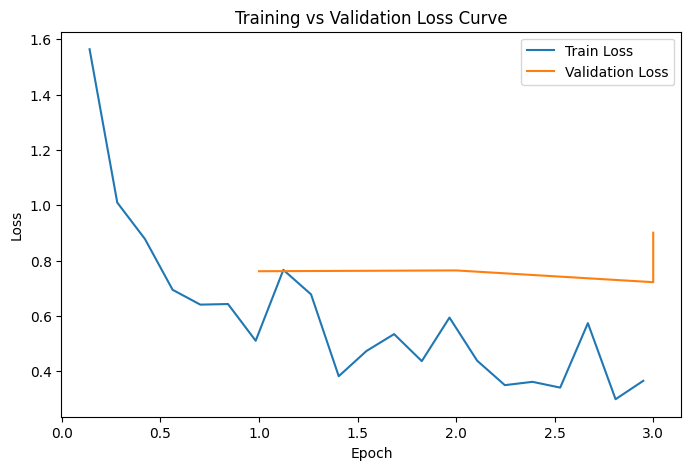

In [94]:
df_log = pd.DataFrame(pubmed_log_history)

train_df = df_log[df_log["loss"].notna()]
eval_df  = df_log[df_log["eval_loss"].notna()]

plt.figure(figsize=(8,5))
plt.plot(train_df["epoch"], train_df["loss"], label="Train Loss")
plt.plot(eval_df["epoch"], eval_df["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.show()

The training loss keeps decreasing steadily, meaning the model continues to learn and fit the training data better over time. The validation loss stays almost flat and does not decrease much, which suggests the model is improving mainly on the training set and not gaining much additional benefit on unseen data.

### 3.2. BioClinicalBERT 

ioClinicalBERT is a BERT model further pretrained on clinical text from electronic health records, making it more familiar with medical terminology and documentation style. It is designed to perform better on clinical NLP tasks than general-domain BERT models because it captures how healthcare professionals actually write and describe medical information.

The fine-tuning procedure is the same as previously.

In [108]:
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [109]:
max_length = 512  

def tokenize_with_labels(batch):
    # tokenize text
    enc = tokenizer(
        batch["abstract"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )
    # attach labels explicitly
    enc["labels"] = batch["label_id"]
    return enc

In [110]:
# Load cleaned CSVs
train_df = pd.read_csv("pubmed_clean_train.csv")
val_df   = pd.read_csv("pubmed_clean_val.csv")
test_df  = pd.read_csv("pubmed_clean_test.csv")

# Keep only necessary columns
train_df = train_df[["abstract", "label_id"]]
val_df   = val_df[["abstract", "label_id"]]
test_df  = test_df[["abstract", "label_id"]]

In [111]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"],
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([0.5011, 2.2150, 2.8214, 0.3548, 7.1818, 4.1579])


In [116]:
# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

In [117]:
train_ds = train_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
val_ds = val_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
test_ds = test_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)

train_ds.set_format(type="torch")
val_ds.set_format(type="torch")
test_ds.set_format(type="torch")

print(train_ds[0].keys())

Map: 100%|██████████| 610/610 [00:00<00:00, 8575.01 examples/s]

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])


In [118]:
num_labels = 6

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)

training_args = TrainingArguments(
    output_dir="bioclinical_bert_runs",   
    num_train_epochs=3,                   
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=2,
    eval_strategy="epoch"    
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [119]:
model_label = "BioClinicalBERT"

In [120]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,  # your existing metrics function
)

In [121]:
trainer.train()

val_results = trainer.evaluate(eval_dataset=val_ds)
print("Validation (BioClinicalBERT):", val_results)

test_results = trainer.evaluate(eval_dataset=test_ds)
print("Test (BioClinicalBERT):", test_results)

trainer.save_model(f"{model_label}_final")
tokenizer.save_pretrained(f"{model_label}_final")

all_results[model_label] = {
    "val": val_results,
    "test": test_results,
}

/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Roc Auc Macro
1,0.810900,0.790348,0.850575,0.643794,0.756572,0.700191,0.960911
2,0.757300,0.734174,0.899836,0.737106,0.781521,0.741740,0.970471
3,0.447000,0.778721,0.912972,0.770729,0.771744,0.783321,0.969954


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/One

Validation (BioClinicalBERT): {'eval_loss': 0.7787208557128906, 'eval_accuracy': 0.9129720853858785, 'eval_f1_macro': 0.7707292502561517, 'eval_precision_macro': 0.7717439545071453, 'eval_recall_macro': 0.78332133467066, 'eval_roc_auc_macro': 0.9699535177892175, 'eval_runtime': 16.9226, 'eval_samples_per_second': 35.987, 'eval_steps_per_second': 2.305, 'epoch': 3.0}


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Test (BioClinicalBERT): {'eval_loss': 0.8628163933753967, 'eval_accuracy': 0.8950819672131147, 'eval_f1_macro': 0.6781064677052915, 'eval_precision_macro': 0.6804432469066616, 'eval_recall_macro': 0.6935947025377311, 'eval_roc_auc_macro': 0.9792393482724217, 'eval_runtime': 16.6947, 'eval_samples_per_second': 36.539, 'eval_steps_per_second': 2.336, 'epoch': 3.0}


BioClinicalBERT shows steadily improving performance with each epoch, with accuracy rising from 0.85 to 0.91 and macro-F1 improving from 0.64 to 0.77. The validation loss decreases overall, which suggests the model is learning and not strongly overfitting. Overall, the metrics indicate that BioClinicalBERT can classify the publication types reasonably well, though it performs worse than PubMedBERT, likely because it is optimized for clinical notes rather than research abstracts.

In [122]:
bioclinical_log_history = trainer.state.log_history

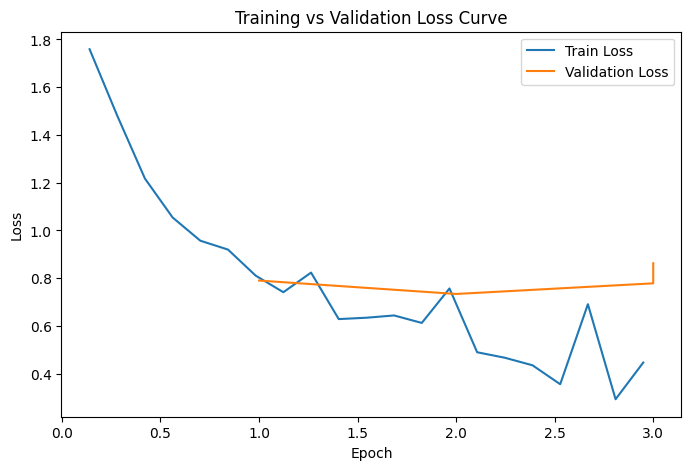

In [123]:
df_log = pd.DataFrame(bioclinical_log_history)

train_df = df_log[df_log["loss"].notna()]
eval_df  = df_log[df_log["eval_loss"].notna()]

plt.figure(figsize=(8,5))
plt.plot(train_df["epoch"], train_df["loss"], label="Train Loss")
plt.plot(eval_df["epoch"], eval_df["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.show()

### 3.3. Baseline BERT

BERT-base is a general purpose transformer language model trained on large English text collections such as Wikipedia and BooksCorpus. Unlike PubMedBERT or BioClinicalBERT, it is not specialized for biomedical or clinical vocabulary, so it serves as a neutral “baseline” to compare how much domain specific pretraining helps for this task. I would assume that this one will perform the worst out of the already existing three models, let's see its performance.

In [124]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [125]:
max_length = 512  

def tokenize_with_labels(batch):
    # tokenize text
    enc = tokenizer(
        batch["abstract"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )
    # attach labels explicitly
    enc["labels"] = batch["label_id"]
    return enc

In [126]:
# Load cleaned CSVs
train_df = pd.read_csv("pubmed_clean_train.csv")
val_df   = pd.read_csv("pubmed_clean_val.csv")
test_df  = pd.read_csv("pubmed_clean_test.csv")

# Keep only necessary columns
train_df = train_df[["abstract", "label_id"]]
val_df   = val_df[["abstract", "label_id"]]
test_df  = test_df[["abstract", "label_id"]]

In [127]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"],
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([0.5011, 2.2150, 2.8214, 0.3548, 7.1818, 4.1579])


In [129]:
# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

In [130]:
train_ds = train_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
val_ds = val_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
test_ds = test_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)

train_ds.set_format(type="torch")
val_ds.set_format(type="torch")
test_ds.set_format(type="torch")

print(train_ds[0].keys())

Map: 100%|██████████| 610/610 [00:00<00:00, 8718.04 examples/s]

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])


In [131]:
num_labels = 6

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)

training_args = TrainingArguments(
    output_dir="bert_base_runs",   
    num_train_epochs=3,                   
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=2,
    eval_strategy="epoch"    
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [132]:
model_label = "BERT-base"

In [133]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,  
)

trainer.train()

val_results = trainer.evaluate(eval_dataset=val_ds)
print("Validation (BERT baseline):", val_results)

test_results = trainer.evaluate(eval_dataset=test_ds)
print("Test (BERT baseline):", test_results)

trainer.save_model(f"{model_label}_final")
tokenizer.save_pretrained(f"{model_label}_final")

all_results[model_label] = {
    "val": val_results,
    "test": test_results,
}

/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Roc Auc Macro
1,0.610400,0.692840,0.865353,0.644283,0.627655,0.694400,0.970937
2,0.686800,0.728243,0.911330,0.708761,0.744678,0.737421,0.974538
3,0.336000,0.692585,0.917898,0.751671,0.795520,0.763577,0.977661


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/One

Validation (BERT baseline): {'eval_loss': 0.6925851702690125, 'eval_accuracy': 0.9178981937602627, 'eval_f1_macro': 0.7516714607509886, 'eval_precision_macro': 0.7955201713180436, 'eval_recall_macro': 0.7635772696679743, 'eval_roc_auc_macro': 0.9776611790054792, 'eval_runtime': 16.628, 'eval_samples_per_second': 36.625, 'eval_steps_per_second': 2.345, 'epoch': 3.0}


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Test (BERT baseline): {'eval_loss': 0.7332115173339844, 'eval_accuracy': 0.9098360655737705, 'eval_f1_macro': 0.7151188705728599, 'eval_precision_macro': 0.7117991949570897, 'eval_recall_macro': 0.7330343738664579, 'eval_roc_auc_macro': 0.9823645778319384, 'eval_runtime': 16.9603, 'eval_samples_per_second': 35.966, 'eval_steps_per_second': 2.299, 'epoch': 3.0}


Baseline BERT shows solid performance on the task despite not being trained on biomedical text. Accuracy improves steadily from 0.87 in epoch 1 to 0.92 by epoch 3, and F1 Macro also rises from 0.64 to 0.75, indicating better balance across classes rather than just predicting the majority one.

Precision and recall also improve over epochs, meaning the model becomes better at both correctly identifying classes and retrieving minority ones. The ROC-AUC stays high (0.97), showing the classifier is good at ranking the correct class even when predictions are uncertain.

Baseline BERT achieves lower performance than PubMedBERT and BioClinicalBERT, especially in F1 and recall. This suggests that a general language model has a harder time understanding biomedical abstracts compared to models trained on medical literature. 

At this point, I can say that my gut was correct.

In [134]:
baseline_bert_log_history = trainer.state.log_history

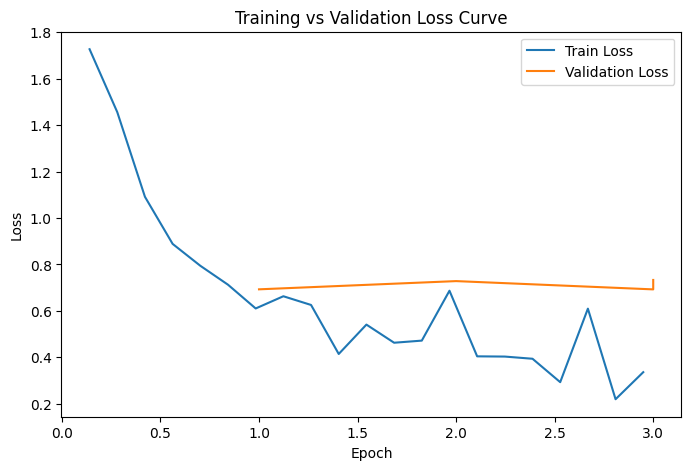

In [135]:
df_log = pd.DataFrame(baseline_bert_log_history)

train_df = df_log[df_log["loss"].notna()]
eval_df  = df_log[df_log["eval_loss"].notna()]

plt.figure(figsize=(8,5))
plt.plot(train_df["epoch"], train_df["loss"], label="Train Loss")
plt.plot(eval_df["epoch"], eval_df["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.show()

### 3.4. TinyBert

After testing 3 bigger transformed based models, I decided that it would be a great comparison, also to check a smaller one - TinyBert.

TinyBERT is a lightweight transformer model created through knowledge distillation, where a large BERT model teaches a smaller one. It is optimized for deployment in resource limited environments such as mobile devices or real-time applications, while preserving reasonable language understanding performance.

In [157]:
model_name = "huawei-noah/TinyBERT_General_4L_312D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [158]:
max_length = 512  

def tokenize_with_labels(batch):
    # tokenize text
    enc = tokenizer(
        batch["abstract"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )
    # attach labels explicitly
    enc["labels"] = batch["label_id"]
    return enc

In [159]:
# Load cleaned CSVs
train_df = pd.read_csv("pubmed_clean_train.csv")
val_df   = pd.read_csv("pubmed_clean_val.csv")
test_df  = pd.read_csv("pubmed_clean_test.csv")

# Keep only necessary columns
train_df = train_df[["abstract", "label_id"]]
val_df   = val_df[["abstract", "label_id"]]
test_df  = test_df[["abstract", "label_id"]]

In [160]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"],
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([0.5011, 2.2150, 2.8214, 0.3548, 7.1818, 4.1579])


In [161]:
# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

In [162]:
train_ds = train_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
val_ds = val_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)
test_ds = test_ds.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=["abstract", "label_id"]
)

train_ds.set_format(type="torch")
val_ds.set_format(type="torch")
test_ds.set_format(type="torch")

Map: 100%|██████████| 610/610 [00:00<00:00, 8021.34 examples/s]


Because of the size of the TinyBert model, it is needed to apply a bigger number of epochs.

In [163]:
num_labels = 6

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)

training_args = TrainingArguments(
    output_dir="tinybert_runs",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=2,
    eval_strategy="epoch",  
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [164]:
model_label = "TinyBERT"

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,  
)

trainer.train()

val_results = trainer.evaluate(eval_dataset=val_ds)
print("Validation (BERT baseline):", val_results)

test_results = trainer.evaluate(eval_dataset=test_ds)
print("Test (BERT baseline):", test_results)

trainer.save_model(f"{model_label}_final")
tokenizer.save_pretrained(f"{model_label}_final")

all_results[model_label] = {
    "val": val_results,
    "test": test_results,
}

/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Roc Auc Macro
1,1.436900,1.440609,0.776683,0.397444,0.389650,0.418181,0.873043
2,1.204100,1.221581,0.798030,0.432025,0.431591,0.455113,0.899821
3,0.994300,1.103858,0.819376,0.503306,0.533197,0.524234,0.926873
4,0.792900,1.205186,0.837438,0.546699,0.554669,0.544664,0.923111
5,0.640400,1.033923,0.844007,0.552151,0.568440,0.571409,0.931738
6,0.660000,1.158707,0.840722,0.558400,0.582453,0.560958,0.936823
7,0.568900,1.167259,0.839080,0.544242,0.608748,0.551191,0.937911
8,0.529500,1.121890,0.824302,0.546792,0.600644,0.564121,0.941692
9,0.660500,1.071486,0.847291,0.577232,0.605598,0.585849,0.944894
10,0.417900,1.085278,0.848933,0.570577,0.603515,0.577744,0.943020


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/Weronika/Library/CloudStorage/One

Validation (BERT baseline): {'eval_loss': 1.0852775573730469, 'eval_accuracy': 0.8489326765188834, 'eval_f1_macro': 0.5705773158418508, 'eval_precision_macro': 0.6035151473954531, 'eval_recall_macro': 0.5777442683364723, 'eval_roc_auc_macro': 0.9430200373142236, 'eval_runtime': 2.4647, 'eval_samples_per_second': 247.086, 'eval_steps_per_second': 15.823, 'epoch': 10.0}


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/LLM/LLM_final/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Test (BERT baseline): {'eval_loss': 1.0830650329589844, 'eval_accuracy': 0.8475409836065574, 'eval_f1_macro': 0.5491615760413714, 'eval_precision_macro': 0.5583005533368031, 'eval_recall_macro': 0.5564789882780887, 'eval_roc_auc_macro': 0.9513703491548736, 'eval_runtime': 2.3937, 'eval_samples_per_second': 254.832, 'eval_steps_per_second': 16.293, 'epoch': 10.0}


TinyBERT performs noticeably worse than the larger biomedical models, with lower accuracy and macro-F1 scores across epochs, indicating difficulty in capturing the nuances of biomedical abstracts. The validation loss stays relatively high compared to training loss, suggesting underfitting rather than overfitting — the model simply lacks representational capacity for this domain. Overall, TinyBERT is efficient and lightweight, but the performance trade-off is clear when compared to PubMedBERT, BioClinicalBERT and baseline BERT.

In [165]:
tinyBERT_log_history = trainer.state.log_history

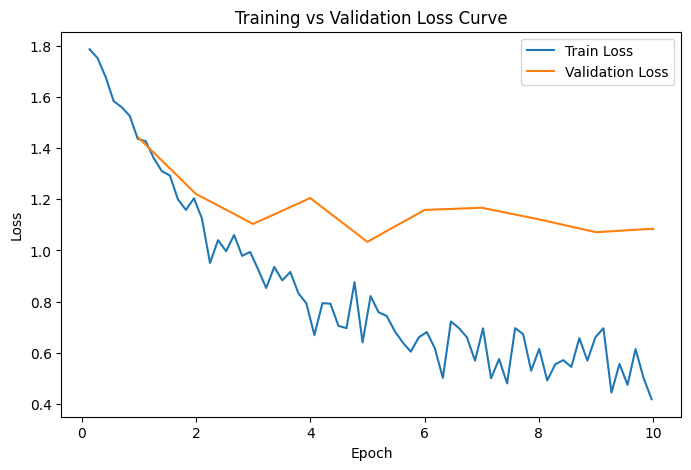

In [166]:
df_log = pd.DataFrame(tinyBERT_log_history)

train_df = df_log[df_log["loss"].notna()]
eval_df  = df_log[df_log["eval_loss"].notna()]

plt.figure(figsize=(8,5))
plt.plot(train_df["epoch"], train_df["loss"], label="Train Loss")
plt.plot(eval_df["epoch"], eval_df["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.show()

### 3.5. Decision Tree

I have already fine-tuned 4 LLM models, but I out of curiosity I decided that it would be interesting also to compare the results with one of the Machine Learning models. The assumption wanted to make, to make a 'fair' comparison, was that I will not focus on additional features from the original dataset(so no extra feature engineering), I will just focus on abstract and my target variable. I also decided to fine-tune it.

In [173]:
train_df = pd.read_csv("pubmed_clean_train.csv")
val_df   = pd.read_csv("pubmed_clean_val.csv")
test_df  = pd.read_csv("pubmed_clean_test.csv")

X_train, y_train = train_df["abstract"].values, train_df["label_id"].values
X_val,   y_val   = val_df["abstract"].values,   val_df["label_id"].values
X_test,  y_test  = test_df["abstract"].values,  test_df["label_id"].values

In [174]:
# recover label names (sorted by ID) for reports and plots
all_df = pd.concat([train_df, val_df, test_df], axis=0)
id2name = (
    all_df[["label_id", "label_name"]]
    .drop_duplicates()
    .sort_values("label_id")
)
label_names = id2name["label_name"].tolist()

The Decision Tree algorithm does not have a built in vectorizer, which would transform the words into the numerical representation. That is why I need to aply the vecotrizier on my own - TF-IDF.

In [175]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=50_000
)

The next piece of code converts the abstract text into TF-IDF numerical vectors, fitting the vocabulary only on the training set and applying the same transformation to validation and test sets.

In [176]:
X_train_t = tfidf.fit_transform(X_train)
X_val_t   = tfidf.transform(X_val)
X_test_t  = tfidf.transform(X_test)

In the next part, a Decision Tree model and a grid of possible hyperparameters are defined.
Then, a 5-fold stratified cross-validation search is run to find which hyperparameter combination gives the best macro F1 score.
Finally, the best-performing tree from the search is selected and used as the final classifier.

In [177]:
base_tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

param_grid = {
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train_t, y_train)

print("Best params from GridSearchCV:", grid.best_params_)
print("Best CV macro F1:", grid.best_score_)

clf = grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params from GridSearchCV: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV macro F1: 0.5010376117213468


In the final part, a helper function is defined that takes a trained model and computes standard classification metrics such as accuracy, macro-F1, precision, and recall. Then, the function also prints the full classification report and visualizes the confusion matrix so performance can be inspected per class.

Finally, this evaluation function is applied to both the validation and test sets to assess how well the Decision Tree generalizes.


=== Validation set ===
Accuracy:       0.6864
F1 (macro):     0.4812
Precision (mac):0.4691
Recall (macro): 0.4996

Classification report:
                             precision    recall  f1-score   support

               case_reports     0.8131    0.8571    0.8345       203
          comparative_study     0.4510    0.5000    0.4742        46
                  editorial     0.3200    0.4444    0.3721        36
         historical_article     0.7791    0.6783    0.7252       286
                       news     0.1053    0.1429    0.1212        14
randomized_controlled_trial     0.3462    0.3750    0.3600        24

                   accuracy                         0.6864       609
                  macro avg     0.4691    0.4996    0.4812       609
               weighted avg     0.7060    0.6864    0.6936       609



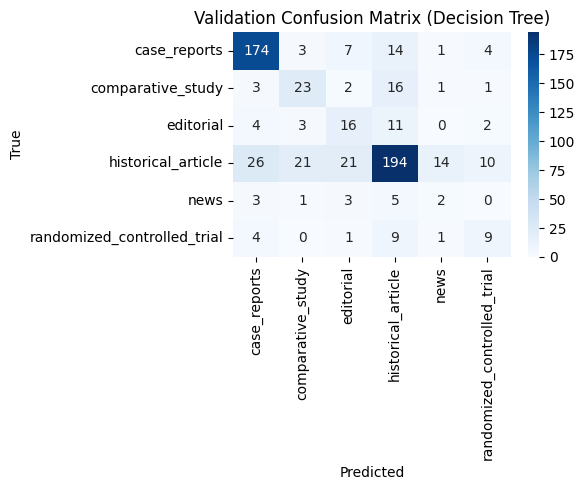


=== Test set ===
Accuracy:       0.7230
F1 (macro):     0.4889
Precision (mac):0.4913
Recall (macro): 0.4919

Classification report:
                             precision    recall  f1-score   support

               case_reports     0.8439    0.8522    0.8480       203
          comparative_study     0.4490    0.4783    0.4632        46
                  editorial     0.2308    0.3333    0.2727        36
         historical_article     0.8132    0.7762    0.7943       286
                       news     0.1111    0.0714    0.0870        14
randomized_controlled_trial     0.5000    0.4400    0.4681        25

                   accuracy                         0.7230       610
                  macro avg     0.4913    0.4919    0.4889       610
               weighted avg     0.7326    0.7230    0.7268       610



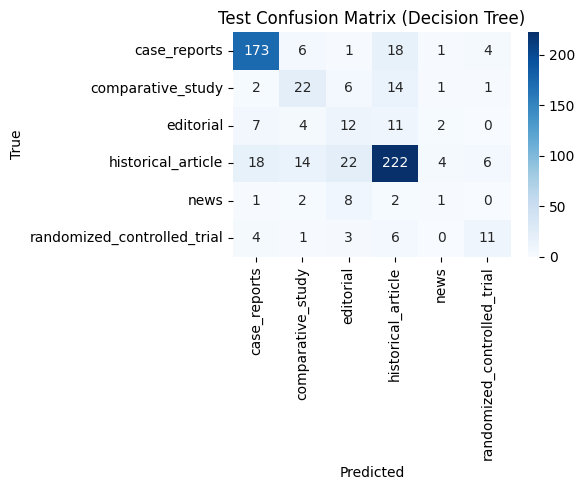

In [185]:
def evaluate_tree(name, model, X, y, label_names):
    preds = model.predict(X)

    acc = accuracy_score(y, preds)
    f1  = f1_score(y, preds, average="macro")
    prec = precision_score(y, preds, average="macro", zero_division=0)
    rec  = recall_score(y, preds, average="macro", zero_division=0)

    print(f"\n=== {name} set ===")
    print(f"Accuracy:       {acc:.4f}")
    print(f"F1 (macro):     {f1:.4f}")
    print(f"Precision (mac):{prec:.4f}")
    print(f"Recall (macro): {rec:.4f}\n")

    print("Classification report:")
    print(classification_report(y, preds, target_names=label_names, digits=4))

    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=label_names,
        yticklabels=label_names,
        cmap="Blues"
    )
    plt.title(f"{name} Confusion Matrix (Decision Tree)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


evaluate_tree("Validation", clf, X_val_t, y_val, label_names)
evaluate_tree("Test",       clf, X_test_t, y_test, label_names)

The Decision Tree achieved an overall accuracy of 0.723, showing that it was able to extract meaningful patterns from the TF-IDF text features. Performance was strong for high-frequency labels such as case reports and historical articles, where the model reached high F1-scores. However, the model struggled with minority labels like news and editorial, which received very low F1-scores due to limited training examples. Overall, the results indicate that the Decision Tree can form a useful baseline, but its performance varies substantially across labels depending on class support.

## 4. Models' Comparison

For models comparison it is necessary to create the key classification metrics for the Decision Tree in the same format as the transformer models and stores them in the unified all_results dictionary for comparison.

In [ ]:
def tree_metrics(model, X, y):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    f1_mac = f1_score(y, preds, average="macro")
    prec_mac = precision_score(y, preds, average="macro", zero_division=0)
    rec_mac = recall_score(y, preds, average="macro", zero_division=0)

    return {
        "eval_accuracy": acc,
        "eval_f1_macro": f1_mac,
        "eval_precision_macro": prec_mac,
        "eval_recall_macro": rec_mac,
        "eval_roc_auc_macro": np.nan,   
        "eval_loss": np.nan,           
    }

tree_val_metrics  = tree_metrics(clf, X_val_t,  y_val)
tree_test_metrics = tree_metrics(clf, X_test_t, y_test)

all_results["DecisionTree"] = {
    "val": tree_val_metrics,
    "test": tree_test_metrics,
}


I collected the validation and test metrics from all models into a single table, organized the metrics by model, rounded them for clarity, and printed the final comparison table in both plain and markdown format.

In [188]:
metric_names = ["loss", "accuracy", "f1_macro",
                "precision_macro", "recall_macro", "roc_auc_macro"]

rows = []

for model_name, res in all_results.items():
    row = {"model": model_name}
    for split in ["val", "test"]:
        m = res[split]
        for metric in metric_names:
            key = f"eval_{metric}"
            row[f"{metric}_{split}"] = m.get(key, np.nan)
    rows.append(row)

df_models = pd.DataFrame(rows).set_index("model")

# round for readability
df_models = df_models.round(4)

print(df_models)
print("\nAs markdown:\n")
print(df_models.to_markdown())

                 loss_val  accuracy_val  f1_macro_val  precision_macro_val  \
model                                                                        
PubMedBERT         0.7216        0.9376        0.8237               0.8240   
BioClinicalBERT    0.7787        0.9130        0.7707               0.7717   
BERT-base          0.6926        0.9179        0.7517               0.7955   
TinyBERT           1.0853        0.8489        0.5706               0.6035   
DecisionTree          NaN        0.6864        0.4812               0.4691   

                 recall_macro_val  roc_auc_macro_val  loss_test  \
model                                                             
PubMedBERT                 0.8271             0.9750     0.9006   
BioClinicalBERT            0.7833             0.9700     0.8628   
BERT-base                  0.7636             0.9777     0.7332   
TinyBERT                   0.5777             0.9430     1.0831   
DecisionTree               0.4996                Na

PubMedBERT achieved the best overall performance among all tested models. It reached both high validation and test accuracy above 0.92 and maintained strong macro F1 scores around 0.80, meaning it handled all classes relatively well and not only the most frequent ones. Its ROC AUC scores were also very high, showing that the model ranked the correct class with high confidence. This suggests that biomedical pretraining on PubMed abstracts was highly beneficial for this publication type classification task.

BioClinicalBERT also performed competitively but slightly worse than PubMedBERT across most metrics. Its accuracy and macro F1 values were lower and the drop was most noticeable in the test F1 score. This makes sense because BioClinicalBERT is pretrained largely on clinical notes, which have a different style and vocabulary than research abstracts.

BERT-base performed surprisingly well considering it was not trained on biomedical text. It reached above 0.90 accuracy and strong ROC AUC, but its macro F1 lagged behind PubMedBERT. This suggests that domain knowledge gives PubMedBERT an advantage especially in minority classes, but the baseline Transformer still extracts useful signals from the abstracts.

TinyBERT showed a noticeable drop in performance across all metrics. It lost roughly twenty to thirty points of macro F1 compared to PubMedBERT, indicating difficulty capturing the complexity of biomedical writing with such a compressed architecture. While its results are reasonable for a tiny model, the performance tradeoff is clear.

Finally, the Decision Tree model reached the lowest performance with macro F1 below 0.50 and accuracy below 0.75. This confirms that simple classical ML models struggle with biomedical text classification even with TF-IDF features, while Transformer architectures handle semantic and contextual information much better.

## 5. Conclusions 

Several aspects of the project were carried out effectively. The dataset was collected directly from PubMed and carefully labeled using publication type tags, which provided a realistic and domain-relevant classification task. Multiple transformer models were evaluated, including domain specific variants such as PubMedBERT and BioClinicalBERT, allowing for meaningful comparisons. The evaluation used appropriate metrics such as macro F1 and ROC AUC, which are more informative than accuracy for potentially imbalanced multiclass problems. Additionally, a classical machine learning baseline was included to contextualize the performance gains offered by modern transformer architectures.

The experiments showed that transformer-based models clearly outperformed the traditional machine learning baseline on the biomedical publication classification task. Among all evaluated models, PubMedBERT achieved the best overall performance across accuracy, macro F1 and ROC AUC, indicating that pretraining directly on biomedical abstracts is highly beneficial for this type of data. BioClinicalBERT performed slightly worse, likely due to its pretraining domain being closer to clinical narratives rather than research literature.

There are also aspects of the project that could be improved. The dataset was limited in size and class balance due to how it was collected from PubMed and gathering a more balanced dataset could lead to stronger and more stable results. The problem was treated as single label classification, although some biomedical articles may actually belong to more than one category, which opens the possibility of testing multilabel models. 

I would also like to highlight that at some point the project was difficult in its triviality. The reason is that at the beginning finding a good target, which would not learn from the abstractt, was not a simple task. I had a few tries, before I succedeed with satisfactory results. Also I faced some limitations from the API side, for example while trying to find the suitable information to fetch, a few 505 errors occured. Till now I am not sure, if it was a website's breake or my fault, because of too frequent fetches. 

Overall, I am satisfied with the performance achieved in this project. The transformer-based models, particularly PubMedBERT, demonstrated strong predictive ability on biomedical publication type classification, achieving consistently high accuracy and macrolevel metrics. Even the smaller baselines provided a valuable reference point and confirmed that domain specific pretraining contributes significantly to performance. 